# Training Results Analyzis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [79]:
def read_metrics(name, version):
  df = pd.read_csv(f"logs/{name}/version_{version}/metrics.csv")
  df = df.groupby("epoch", as_index=False).first()
  return df

def plot_speech_metrics(dfs, labels, title):
    assert len(dfs) == len(labels), "one label per dataframe, please"
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (df, label) in enumerate(zip(dfs, labels)):
        color = colors[i % len(colors)]
        ax[0].plot(df["epoch"], df["train_loss"], label=f"{label} (train)", color=color, linestyle="-")
        ax[0].plot(df["epoch"], df["val_loss"], label=f"{label} (val)", color=color, linestyle="--")

    ax[0].set_title("Loss function")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("loss")
    ax[0].legend(fontsize=8)

    for i, (df, label) in enumerate(zip(dfs, labels)):
        color = colors[i % len(colors)]
        ax[1].plot(df["epoch"], df["val_wer"], label=label, color=color, linestyle="-")

    ax[1].set_title("Word Error Rates")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("WER")
    ax[1].set_ylim(0, 1.2)
    ax[1].legend(fontsize=8)

    for i, (df, label) in enumerate(zip(dfs, labels)):
        color = colors[i % len(colors)]
        ax[2].plot(df["epoch"], df["val_cer"], label=label, color=color, linestyle="-")

    ax[2].set_title("Character Error Rates")
    ax[2].set_xlabel("epoch")
    ax[2].set_ylabel("CER")
    ax[2].set_ylim(0, 1.2)
    ax[2].legend(fontsize=8)


    fig.suptitle(title)
    fig.tight_layout()

    return fig

def plot_phonemes_metrics(dfs, labels, title):
    assert len(dfs) == len(labels), "one label per dataframe, please"
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (df, label) in enumerate(zip(dfs, labels)):
        color = colors[i % len(colors)]
        ax[0].plot(df["epoch"], df["train_loss"], label=f"{label} (train)", color=color, linestyle="-")
        ax[0].plot(df["epoch"], df["val_loss"], label=f"{label} (val)", color=color, linestyle="--")

    ax[0].set_title("Loss function")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("loss")
    ax[0].legend(fontsize=8)

    for i, (df, label) in enumerate(zip(dfs, labels)):
        color = colors[i % len(colors)]
        ax[1].plot(df["epoch"], df["val_per"], label=label, color=color)

    ax[1].set_title("Phoneme Error Rates")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("PER")
    ax[1].legend(fontsize=8)
    ax[1].set_ylim(0, 1.2)

    fig.suptitle(title)
    fig.tight_layout()

    return fig

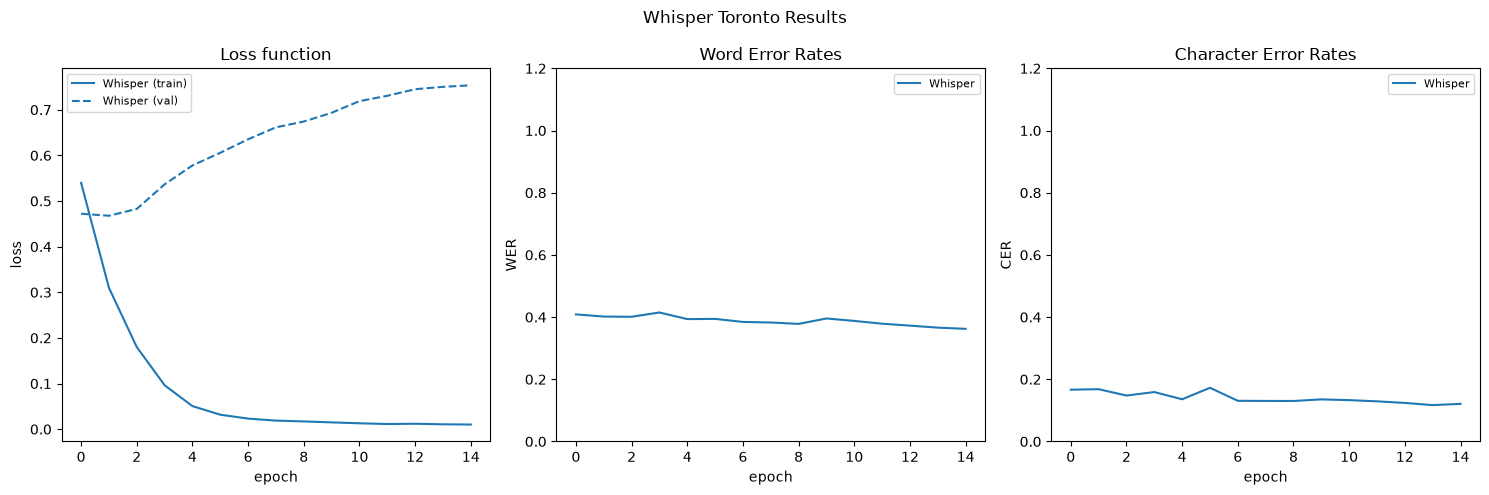

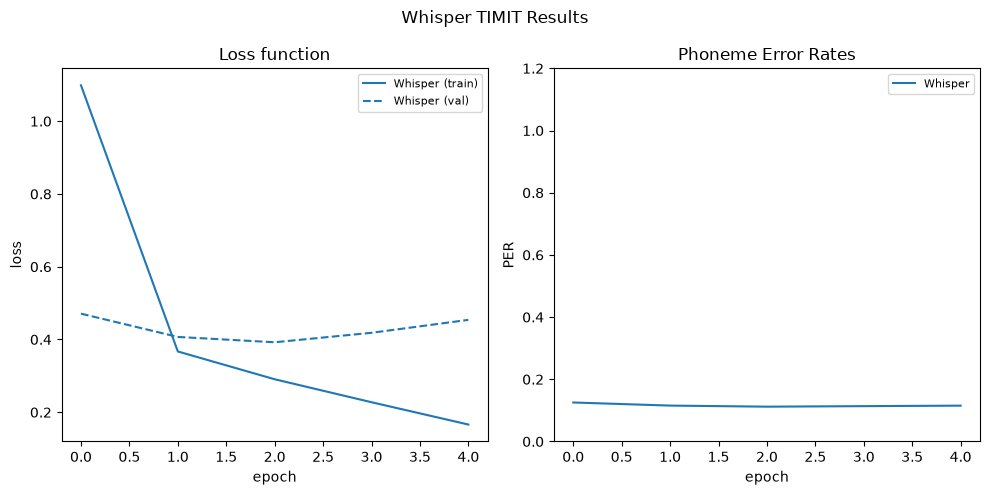

In [80]:
whisper_toronto = read_metrics("whisper", version=2)
whisper_timit = read_metrics("whisper_timit", version=0)

fig = plot_speech_metrics([whisper_toronto], ["Whisper"], "Whisper Toronto Results")
fig.savefig("img/whisper_toronto.png", dpi=300, bbox_inches="tight")

fig = plot_phonemes_metrics([whisper_timit], ["Whisper"], "Whisper TIMIT Results")
fig.savefig("img/whisper_timit.png", dpi=300, bbox_inches="tight")

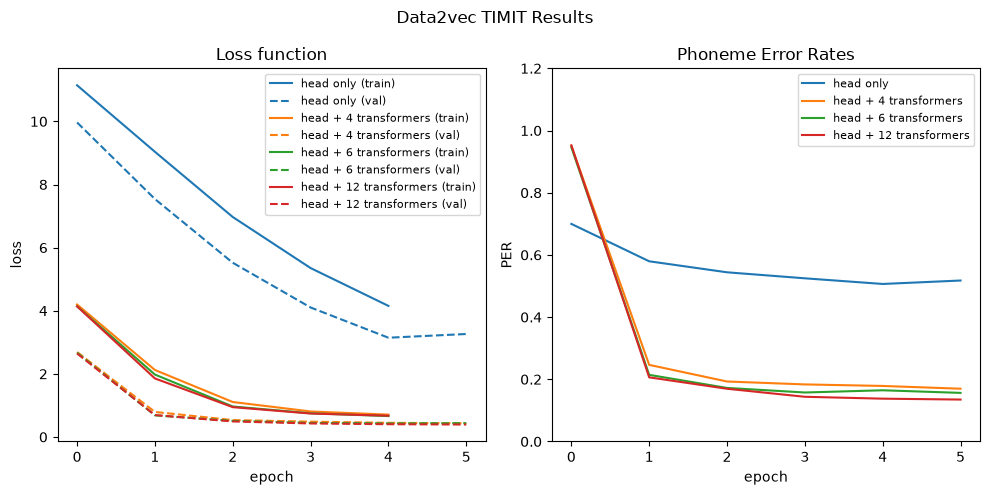

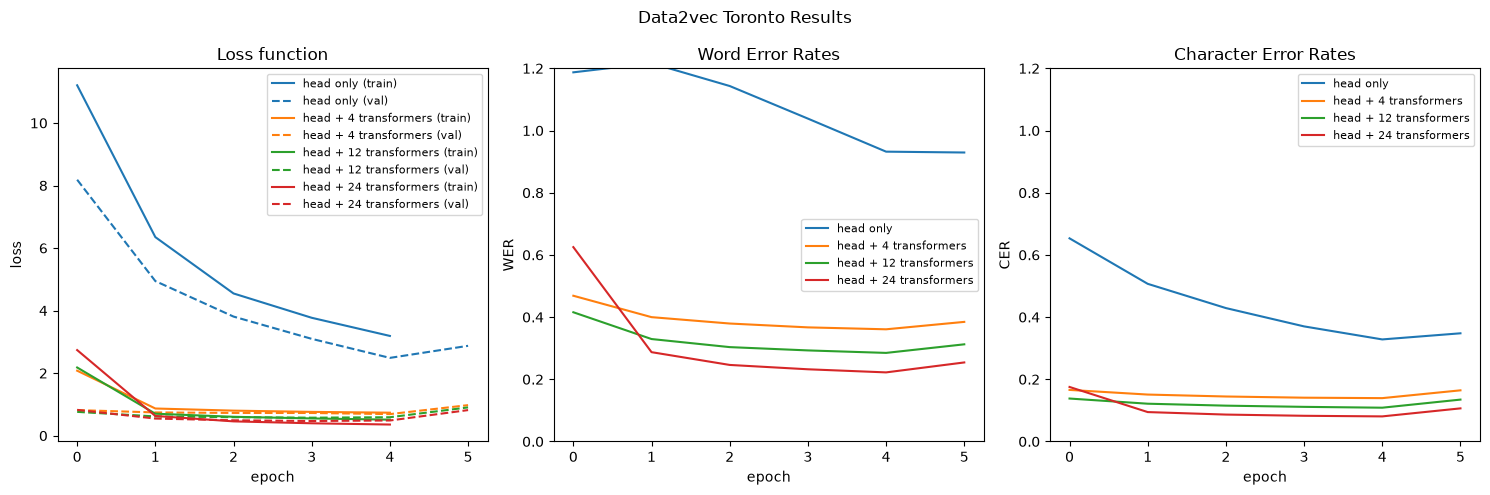

In [82]:
data2vec_timit_0_layers = read_metrics("timit_data2vec_finetune_val_0_layers", version=3)
data2vec_timit_4_layers = read_metrics("timit_data2vec_finetune_val_4_layers", version=1)
data2vec_timit_6_layers = read_metrics("timit_data2vec_finetune_val_6_layers", version=3)
data2vec_timit_12_layers = read_metrics("timit_data2vec_finetune_val_12_layers", version=1)

fig = plot_phonemes_metrics(
  [
    data2vec_timit_0_layers,
    data2vec_timit_4_layers,
    data2vec_timit_6_layers,
    data2vec_timit_12_layers,
  ],
  [
    "head only",
    "head + 4 transformers",
    "head + 6 transformers",
    "head + 12 transformers"
  ],
  "Data2vec TIMIT Results",
)

fig.savefig("img/data2vec_timit.png", dpi=300, bbox_inches="tight")

data2vec_toronto_0_layers = read_metrics("toronto_data2vec_finetune_val_0_layers", version=0)
data2vec_toronto_4_layers = read_metrics("toronto_data2vec_finetune_val_4_layers", version=0)
data2vec_toronto_12_layers = read_metrics("toronto_data2vec_finetune_val_12_layers", version=0)
data2vec_toronto_24_layers = read_metrics("toronto_data2vec_finetune_val_24_layers", version=0)

fig = plot_speech_metrics(
  [
    data2vec_toronto_0_layers,
    data2vec_toronto_4_layers,
    data2vec_toronto_12_layers,
    data2vec_toronto_24_layers,
  ],
  [
    "head only",
    "head + 4 transformers",
    "head + 12 transformers",
    "head + 24 transformers"
  ],
  "Data2vec Toronto Results",
)

fig.savefig("img/data2vec_toronto.png", dpi=300, bbox_inches="tight")